In [1]:
import numpy as np
from scipy.signal import correlate

np.random.seed(42)

In [2]:
def im2col(X, kernel, stride=1, padding=0):

    X = np.pad(
        X,
        ((0, 0), (0, 0),
         (padding, padding),
         (padding, padding))
    )

    N, C, H, W = X.shape
    KH, KW = kernel

    OH = (H - KH) // stride + 1
    OW = (W - KW) // stride + 1

    cols = []

    for i in range(0, OH):
        for j in range(0, OW):

            patch = X[
                :,
                :,
                i*stride:i*stride+KH,
                j*stride:j*stride+KW
            ]

            cols.append(patch.reshape(N, -1))

    return np.stack(cols, axis=1)

In [3]:
def conv2d(X, W, b, stride=1, padding=0):

    N, C, H, W_in = X.shape
    F, _, KH, KW = W.shape

    cols = im2col(
        X, (KH, KW),
        stride, padding
    )

    output = cols @ W.reshape(F, -1).T
    output += b

    OH = (H + 2*padding - KH) // stride + 1
    OW = (W_in + 2*padding - KW) // stride + 1

    output = output.reshape(
        N, OH, OW, F
    ).transpose(0, 3, 1, 2)

    return output

In [4]:
X = np.random.randn(2, 3, 8, 8)

W = np.random.randn(4, 3, 3, 3)

b = np.zeros(4)

print("Input:", X.shape)
print("Filters:", W.shape)

Input: (2, 3, 8, 8)
Filters: (4, 3, 3, 3)


In [5]:
output = conv2d(
    X,
    W,
    b,
    stride=1,
    padding=1
)

print("Output shape:", output.shape)

Output shape: (2, 4, 8, 8)


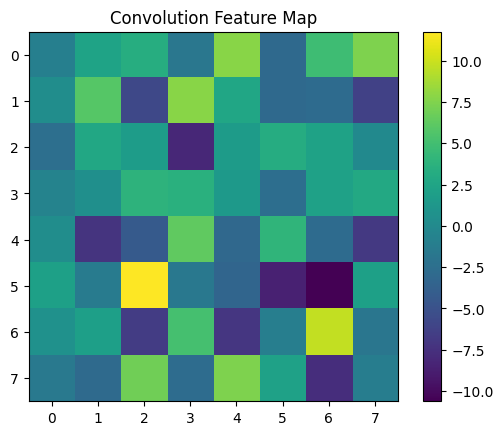

In [6]:
plt = __import__("matplotlib.pyplot", fromlist=["plt"])

plt.imshow(output[0, 0], cmap="viridis")
plt.title("Convolution Feature Map")
plt.colorbar()
plt.show()